In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
x_A = -4
y_A = 6

x_B = 5
y_B = -6

In [3]:
x_M = (x_A + x_B)/2
y_M = (y_A + y_B)/2

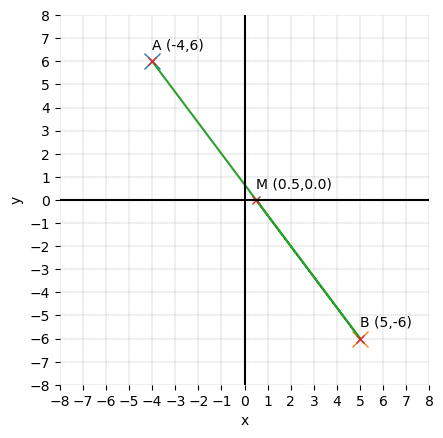

In [19]:
fig,ax = plt.subplots()

plt.plot(x_A,y_A,'x',markersize = 12)
plt.plot(x_B,y_B,'x',markersize = 12)

x_points = [x_A,x_B,x_M]
y_points = [y_A,y_B,y_M]

plt.plot(x_points,y_points)

labels = ['A','B','M']

plt.plot(x_points,y_points,'x')

for label,i,j in zip(labels,x_points,y_points):
    plt.text(i,j+0.5,label + ' ({},{}) '.format(i,j))

plt.xlabel('x')
plt.ylabel('y')
plt.axhline(y = 0,color = 'k',ls = '-')
plt.axvline(x = 0,color = 'k',ls = '-')
plt.xticks(np.arange(-8,8+1,step = 1))
plt.yticks(np.arange(-8,8+1,step = 1))

plt.axis('scaled')#调整为等比例也配置了范围更紧凑

ax.set_xlim(-8,8)
ax.set_ylim(-8,8)

#批量索引语法,相当于有了for函数
ax.spines[['top','right','bottom','left']].set_visible(False)

ax.grid(ls = '--',lw = 0.25,color = '0.5')

In [20]:
x_A = -2
y_A = 3
z_A = 1

x_B = 3
y_B = -1
z_B = -3

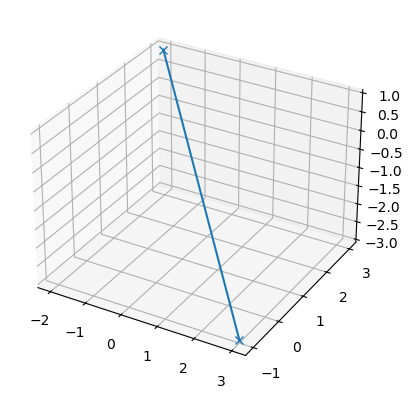

<Figure size 640x480 with 0 Axes>

In [27]:
fig = plt.figure()
ax = fig.add_subplot(projection = '3d')
ax.plot([x_A,x_B],[y_A,y_B],[z_A,z_B],'x',ls = '-')

plt.show()

ax.set_proj_type('ortho')

plt.tight_layout()

plt.tight_layout()
ax.set_xlabel(r'$\it{x}$')
ax.set_ylabel(r'$\it{y}$')
ax.set_zlabel(r'$\it{z}$')
ax.view_init(azim = -135,elev = 30)
ax.xaxis._axinfo['grid'].update({'linewidth':0.25,'linestyle':':'})
ax.yaxis._axinfo['grid'].update({'linewidth':0.25,'linestyle':':'})
ax.zaxis._axinfo['grid'].update({'linewidth':0.25,'linestyle':':'})

In [29]:
import itertools#专用迭代器,更方便的写for这种迭代循环,惰性的节省内存,可计算排列组合
from sklearn.metrics.pairwise import euclidean_distances
import seaborn as sns
from matplotlib import cm

In [31]:
X = np.array([[1,6],[4,6],[1,5],[6,0],
              [3,8],[8,3],[4,1],[3,5],
              [9,2],[5,9],[4,9],[8,4]])

labels = ['a','b','c','d','e','f','g','h','i','j','k','l']

#计算的是近似值,因为对角线用一个颜色,所以够用
#int直接丢掉小数部分,(不是向上也不是向下)
colors = plt.cm.rainbow(np.linspace(0,1,int(len(X)*len(X)/2)))

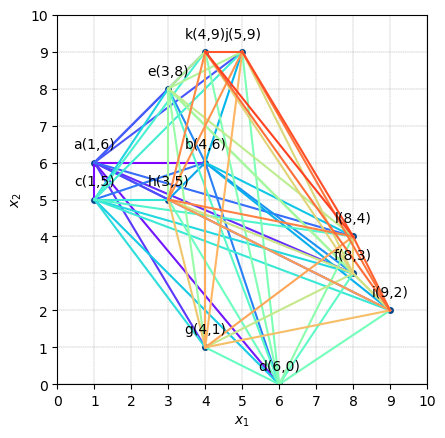

In [42]:
fig,ax = plt.subplots()

#生成组合数,只看最外层维度
for i,d in enumerate(itertools.combinations(X,2)):
    plt.plot([d[0][0],d[1][0]],[d[0][1],d[1][1]],color = colors[i,:])

plt.scatter(x = X[:,0],y = X[:,1],color = np.array([0,68,138])/255.,alpha = 1.0,
            lw = 1,edgecolor = [1,1,1])#如果color是4D格式,不需要再写alpha

for i,(x,y) in enumerate(zip(X[:,0],X[:,1])):
    label = labels[i] + f"({x},{y})"
    #注释函数,考虑到了文本对齐位置和绘制点
        #text函数只考虑绘制点(锚点)没考虑文本对齐位置
    plt.annotate(label,#文本内容
                 (x,y),#文本锚点
                 textcoords = 'offset points',#根据锚点构建新的文本坐标系控制文本偏移量 这里使用相对锚点的屏幕点数偏移
                xytext = (0,10),#文本相对锚点的偏移量(使用了屏幕点数的偏移)向上偏移10个像素
                 ha = 'center')#配置文本本身的对齐位置,默认是左下,ha配置水平为中间,就配置为了中下.va可以配置垂直对齐


ax.set_xticks(np.arange(0,11,1))
ax.set_yticks(np.arange(0,11,1))
ax.set_xlim(0,10)
ax.set_ylim(0,10)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
ax.grid(ls = '--',lw = 0.25,color = '0.5')
ax.set_aspect('equal')

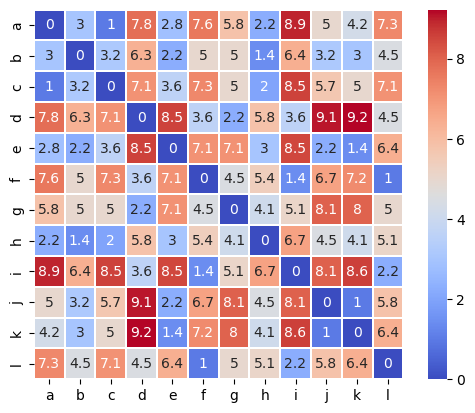

In [45]:
Pairwise_d = euclidean_distances(X)

fig,ax = plt.subplots()

h = sns.heatmap(Pairwise_d,cmap = 'coolwarm',
                #只要配置了lw,自动开启边界
                #square控制小格子的x,y比例等比(不是大矩阵)
                square = True,lw = .05,annot = True,
                xticklabels = labels,yticklabels = labels)

In [51]:
def dist(a,b,c,x_A,y_A):
    dist_AH = np.abs(a*x_A + b*y_A + c) / np.sqrt(a**2 + b**2)

    x_H = (b*(b*x_A - a*y_A) - a*c) / (a**2 + b**2)
    y_H = (a*(-b*x_A + a*y_A) - b*c) / (a**2 + b**2)

    return x_H,y_H,dist_AH

x_A = -4
y_A = 6

a = 1;b = -2;c = -4

x_array = np.linspace(-8,8,10)
y_array = -a/b*x_array - c/b#一次函数,可以转化为表述直线的方程,注意两者是分开的

x_H,y_H,dist_AH = dist(a,b,c,x_A,y_A)

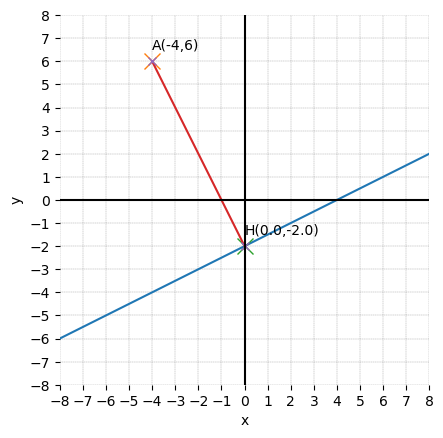

In [55]:
fig,ax = plt.subplots()

plt.plot(x_array,y_array)
plt.plot(x_A,y_A,'x',markersize = 12)
plt.plot(x_H,y_H,'x',markersize = 12)

x_points = [x_A,x_H]
y_points = [y_A,y_H]

plt.plot(x_points,y_points)

labels = ['A','H']

plt.plot(x_points,y_points,'x')

for label,i,j in zip(labels,x_points,y_points):
    plt.text(i,j + 0.5,label + '({},{})'.format(i,j))



plt.xlabel('x')
plt.ylabel('y')
plt.axhline(y = 0,color = 'k',ls = '-')
plt.axvline(x = 0,color = 'k',ls = '-')
plt.xticks(np.arange(-8,8+1,step = 1))
plt.yticks(np.arange(-8,8+1,step = 1))

plt.axis('scaled')

ax.set_xlim(-8,8)
ax.set_ylim(-8,8)

ax.spines[['top','right','bottom','left']].set_visible(False)

ax.grid(ls = '--',lw = 0.25,color = '0.5')

In [56]:
from sympy import lambdify,sqrt
from sympy.abc import x,y

In [59]:
O = [0,0]

num = 301
x_array = np.linspace(-8,8,num)
y_array = np.linspace(-8,8,num)

xx,yy = np.meshgrid(x_array,y_array)

dist_OP = sqrt((x - O[0]) **2 + (y - O[1])**2)

dist_OP_fcn = lambdify([x,y],dist_OP)

dist_OP_zz = dist_OP_fcn(xx,yy)

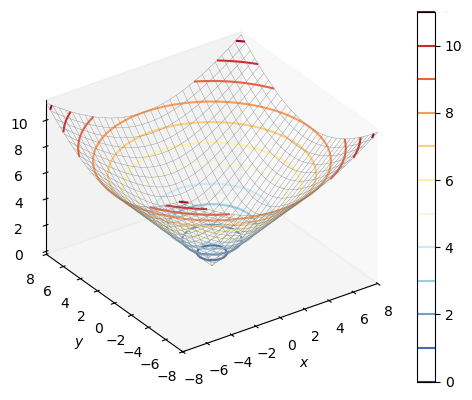

In [68]:
fig,ax = plt.subplots(subplot_kw = {'projection':'3d'})

ax.plot_wireframe(xx,yy,dist_OP_zz,
                  color = '0.5',
                  #r表示row,c表示column
                  rstride = 10,cstride = 10,
                  linewidth = 0.25)

colorbar = ax.contour(xx,yy,dist_OP_zz,
                      levels = np.arange(0,11+1),
                      cmap = 'RdYlBu_r')

fig.colorbar(colorbar,ax = ax)

ax.set_proj_type('ortho')

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$f(x,y)$')

ax.set_xlim(xx.min(),xx.max())
ax.set_ylim(yy.min(),yy.max())

ax.view_init(azim = -125,elev = 30)

ax.grid(False)
plt.show()

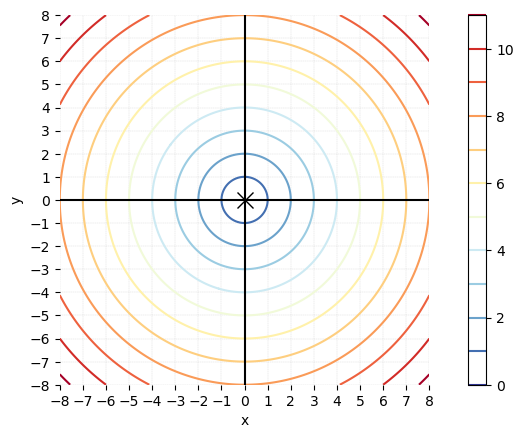

In [71]:
fig,ax = plt.subplots()

plt.plot(O[0],O[1],color = 'k',
         marker = 'x',markersize = 12)

colorbar = ax.contour(xx,yy,dist_OP_zz,
                      levels = np.arange(0,11+1),
                      cmap = 'RdYlBu_r')

#colorbar属于figure级对象 可以理解为一个独立的axis
#colorbar函数可以直接解析可映射对象,ax.colorbar返回的就是这个可映射对象
fig.colorbar(colorbar,ax = ax)#

plt.xlabel('x')
plt.ylabel('y')
plt.axhline(y = 0,color = 'k',ls = '-')
plt.axvline(x = 0,color = 'k',ls = '-')
plt.xticks(np.arange(-10,10+1,step = 1))
plt.yticks(np.arange(-10,10+1,step = 1))

plt.axis('scaled')

ax.set_xlim(xx.min(),xx.max())
ax.set_ylim(yy.min(),yy.max())

ax.spines[['top','right','bottom','left']].set_visible(False)

ax.grid(ls = '--',lw = 0.25,color = '0.8')

In [72]:
O = [0,0]

num = 301
x_array = np.linspace(-8,8,num)
y_array = np.linspace(-8,8,num)

xx,yy = np.meshgrid(x_array,y_array)

dist_OP = (x - O[0]) **2 + (y - O[1])**2

dist_OP_fcn = lambdify([x,y],dist_OP)

dist_OP_zz = dist_OP_fcn(xx,yy)

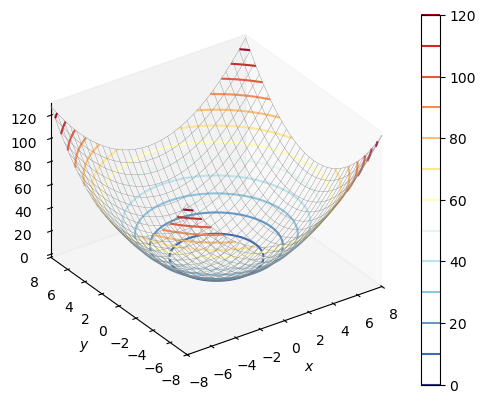

In [77]:
fig,ax = plt.subplots(subplot_kw = {'projection':'3d'})

ax.plot_wireframe(xx,yy,dist_OP_zz,
                  color = '0.5',
                  #r表示row,c表示column
                  rstride = 10,cstride = 10,
                  linewidth = 0.25)

colorbar = ax.contour(xx,yy,dist_OP_zz,
                      levels = np.arange(0,120+1,step = 10),
                      cmap = 'RdYlBu_r')

fig.colorbar(colorbar,ax = ax)

ax.set_proj_type('ortho')

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$f(x,y)$')

ax.set_xlim(xx.min(),xx.max())
ax.set_ylim(yy.min(),yy.max())

ax.view_init(azim = -125,elev = 30)

ax.grid(False)
plt.show()

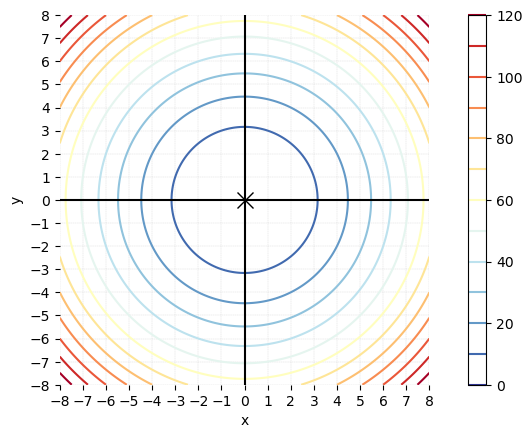

In [78]:
fig,ax = plt.subplots()

plt.plot(O[0],O[1],color = 'k',
         marker = 'x',markersize = 12)

colorbar = ax.contour(xx,yy,dist_OP_zz,
                      levels = np.arange(0,120+1,step = 10),
                      cmap = 'RdYlBu_r')

#colorbar属于figure级对象 可以理解为一个独立的axis
#colorbar函数可以直接解析可映射对象,ax.colorbar返回的就是这个可映射对象
fig.colorbar(colorbar,ax = ax)#

plt.xlabel('x')
plt.ylabel('y')
plt.axhline(y = 0,color = 'k',ls = '-')
plt.axvline(x = 0,color = 'k',ls = '-')
plt.xticks(np.arange(-10,10+1,step = 1))
plt.yticks(np.arange(-10,10+1,step = 1))

plt.axis('scaled')

ax.set_xlim(xx.min(),xx.max())
ax.set_ylim(yy.min(),yy.max())

ax.spines[['top','right','bottom','left']].set_visible(False)

ax.grid(ls = '--',lw = 0.25,color = '0.8')

In [93]:
def plot_fcn(A,B,dist_AX_zz,dist_BX_zz,distance):
    fig,ax = plt.subplots()

    plt.plot(A[0],A[1],color = 'k',marker = 'x',markersize = 12)
    plt.plot(B[0],B[1],color = 'k',marker = 'x',markersize = 12)
    colorbar = ax.contour(xx,yy,dist_AX_zz,levels = np.arange(0,15+1),cmap = 'RdYlBu_r')
    ax.contour(xx,yy,dist_BX_zz,levels = np.arange(0,15+1),cmap = 'RdYlBu_r')

    #levels = 0是特殊等价用法,等价于levels = [0].
    #如果levels = 5是画0条,为0不表示画0条,表示画值为0的等高线
    ax.contour(xx,yy,distance,levels = 0,colors = 'k')
    fig.colorbar(colorbar,ax = ax)

    plt.xlabel('x')
    plt.ylabel('y')
    plt.axhline(y = 0,color = 'k',ls = '-')
    plt.axvline(x = 0,color = 'k',ls = '-')
    plt.xticks(np.arange(-10,10+1,step = 2))
    plt.yticks(np.arange(-10,10+1,step = 2))
    
    plt.axis('scaled')
    
    ax.set_xlim(xx.min(),xx.max())
    ax.set_ylim(yy.min(),yy.max())
    
    ax.spines[['top','right','bottom','left']].set_visible(False)
    
    ax.grid(ls = '--',lw = 0.25,color = '0.8')

In [94]:
A = [4,2]
B = [0,-2]

num = 301

x_array = np.linspace(-8,8,num)
y_array = np.linspace(-8,8,num)

xx,yy = np.meshgrid(x_array,y_array)

dist_AX = sqrt((x - A[0])**2 + (y - A[1])**2)
dist_BX = sqrt((x - B[0])**2 + (y - B[1])**2)

dist_AX_fcn = lambdify([x,y],dist_AX)
dist_BX_fcn = lambdify([x,y],dist_BX)

dist_AX_zz = dist_AX_fcn(xx,yy)
dist_BX_zz = dist_BX_fcn(xx,yy)

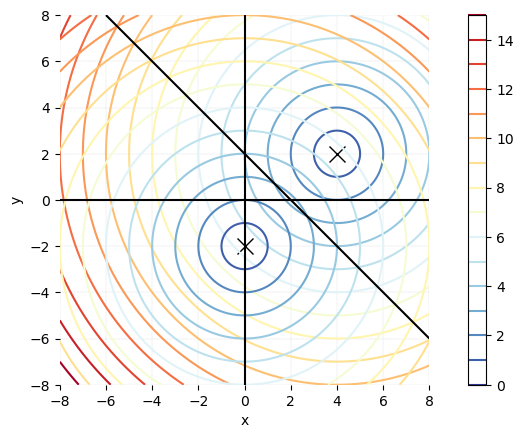

In [95]:
distance = dist_AX_zz - dist_BX_zz
plot_fcn(A,B,dist_AX_zz,dist_BX_zz,distance)

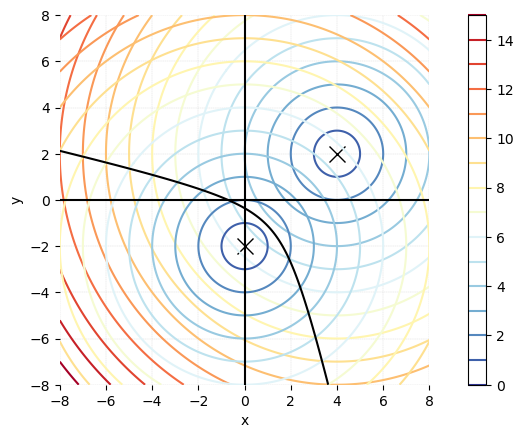

In [96]:
distance = dist_AX_zz - dist_BX_zz - 3
plot_fcn(A,B,dist_AX_zz,dist_BX_zz,distance)

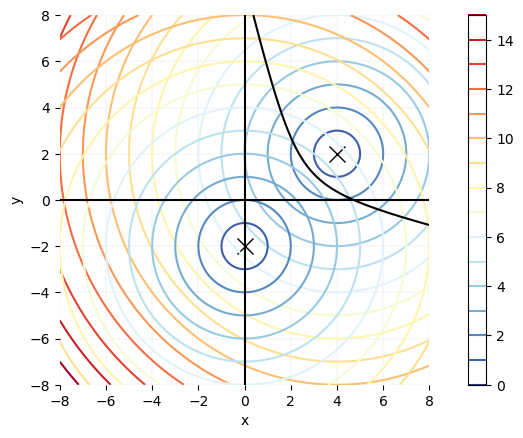

In [97]:
distance = dist_AX_zz - dist_BX_zz + 3
plot_fcn(A,B,dist_AX_zz,dist_BX_zz,distance)

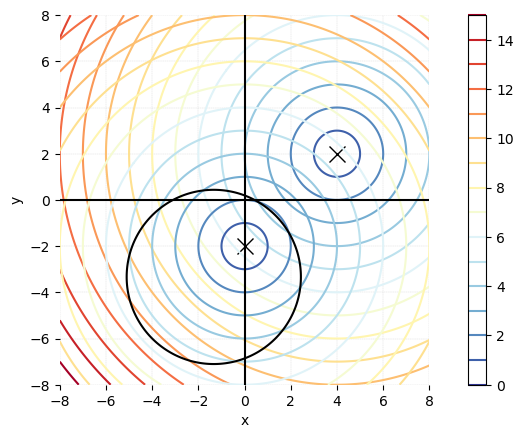

In [98]:
distance = dist_AX_zz - 2*dist_BX_zz
plot_fcn(A,B,dist_AX_zz,dist_BX_zz,distance)

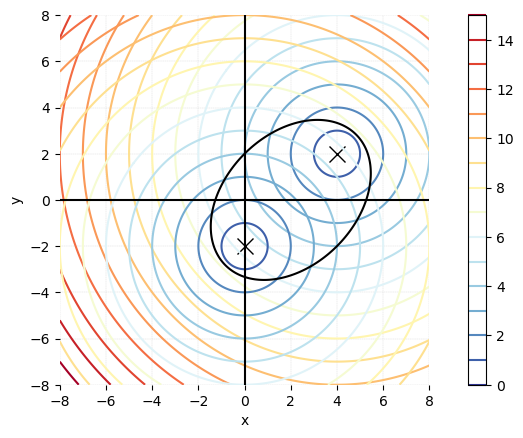

In [99]:
distance = dist_AX_zz + dist_BX_zz - 8
plot_fcn(A,B,dist_AX_zz,dist_BX_zz,distance)